In [1]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [2]:
class Batter(TypedDict):
    run:int
    balls:int
    fours:int
    six:int
    strike_rate:float
    balls_per_boundary:float
    boundary_pct:float
    summary:str


In [3]:
def calc_sr(state:Batter)->Batter:
    sr=(state['run']/state['balls'])
    #state['strike_rate']=sr
    return {'strike_rate':sr}
    #return state

def calc_bpb(state:Batter)->Batter:
    bpb=state['balls']/(state['fours']+state['six'])
    #state['balls_per_boundary']=bpb
    return {'balls_per_boundary':bpb}
    #return state

def calc_boundary_pct(state:Batter)->Batter:
    bndry_pct=(state['fours']*4+state['six']*6)/state['run']
    #state['boundary_pct']=bndry_pct
    #return state
    return {'boundary_pct':bndry_pct}

def summary(state:Batter)->Batter:
    summ=f"""The batter has scored {state['run']} on a strike rate of {state['strike_rate']}, 
    batter has scored {state['boundary_pct']} runs from boundary and 
    used {state['balls_per_boundary']} to hit boundary"""
    return{'summary':summ}
    # state['summary']=summ
    # return state, while returning state in parallel graph will throw error 
    # because each node will consider updating the entire dictionary rather key which makes conflict

In [4]:
graph=StateGraph(Batter)
#creating nodes
graph.add_node('calculate Strike Rate',calc_sr)
graph.add_node('calculate balls per boundary',calc_bpb)
graph.add_node('calculate boundary pct',calc_boundary_pct)
graph.add_node('summary',summary)

#creating edges
graph.add_edge(START,'calculate Strike Rate')
graph.add_edge(START,'calculate balls per boundary')
graph.add_edge(START,'calculate boundary pct')
graph.add_edge('calculate Strike Rate','summary')
graph.add_edge('calculate balls per boundary','summary')
graph.add_edge('calculate boundary pct','summary')
graph.add_edge('summary',END)

#compiling the graph
workflow=graph.compile()

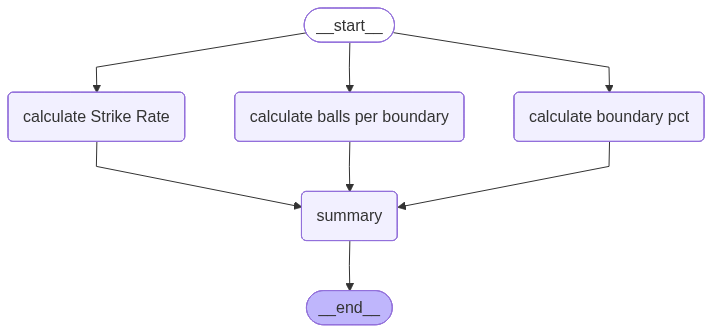

In [5]:
workflow

In [6]:
initial_state={'run':80,'balls':26,'fours': 5,"six":3}

output=workflow.invoke(initial_state)
print(output)

{'run': 80, 'balls': 26, 'fours': 5, 'six': 3, 'strike_rate': 3.076923076923077, 'balls_per_boundary': 3.25, 'boundary_pct': 0.475, 'summary': 'The batter has scored 80 on a strike rate of 3.076923076923077, \n    batter has scored 0.475 runs from boundary and \n    used 3.25 to hit boundary'}
